# Descens de gradient

El descens de gradient és un algorisme d'optimització genèric capaç de trobar solucions a una àmplia varietat de problemes. La idea general darrere del descens de gradient és ajustar els paràmetres d'un model iterativament fins que convergim a un conjunt òptim de paràmetres $\hat{\theta}$ que minimitzi la funció objectiu.

Suposem que esteu perduts a la muntanya amb una boira densa, no podeu veure res, només podeu sentir el terra sota els vostres peus i voleu tornar a casa. Una bona estratègia és moure's en la direcció del pendent més pronunciat. Això és exactament el que fa el descens de gradient.

GD mesura el gradient local de la funció d'error respecte a la funció de paràmetre $\theta$ i va en la direcció del gradient descendent. **Un cop el gradient és zero, hem arribat a un mínim**.

A la pràctica, comencem inicialitzant $\theta$ amb valors aleatoris (això s'anomena **inicialització aleatòria**). Després ho millorem gradualment, fent un pas a la vegada. Cada pas intenta disminuir la funció de cost, fins que convergim a un mínim:

<div style="text-align:center;"><img style="width: 50%;" src="./imgs_regressio/GD.png"></div>

Un paràmetre important en GD és la mida del pas, determinada per l'hiperparàmetre *taxa d'aprenentatge*. Si la taxa d'aprenentatge és massa petita, l'algoritme trigarà molt a convertir-se al mínim, i si la taxa d'aprenentatge és massa gran, l'algoritme pot saltar infinitament entre intervals o fins i tot divergir.

Finalment, no totes les funcions de cost semblen bols agradables i regulars. Hi pot haver forats/crestes/altiplans i tot tipus de terrenys irregulars. Les curvatures de la majoria de les funcions de cost són un repte. Com a resultat, la inicialització dels paràmetres juga un paper important, depenent d'on comencem, podem acabar en un lloc o un altre:

<div style="text-align:center;"><img style="width: 50%;" src="./imgs_regressio/Loss_curvature.png"></div>

Afortunadament, $MSE$ per a la regressió lineal resulta en una funció de pèrdua convexa, és a dir, es garanteix que el mínim trobat és el mínim global de la funció (sense mínims locals, només un **mínim global**). També és una funció contínua amb un pendent que mai canvia de manera interrompuda (funció contínua de Lipschitz).

La funció Cost té forma de bol, però pot ser un bol allargat sense escalat de característiques (perquè el rang dinàmic del paràmetre de cada característica serà diferent):

<div style="text-align:center;"><img style="width: 50%;" src="./imgs_regressio/scaling_effect.png"></div>

Si no es fa escalat de característiques i s'aplica una taxa d'aprenentatge constant per a tots dos paràmetres de característiques, l'algoritme trigarà més a arribar al mínim global.

Avís: Quan utilitzeu el descens de gradient, assegureu-vos que totes les característiques estiguen escalades.

Breument, quan entrenem el model, estem **buscant** efectivament un conjunt de paràmetres que minimitzi la funció de cost. **És una cerca a l'espai de paràmetres del model**

Com més paràmetres tingui el model, com més dimensions tingui l'espai, més difícil serà trobar el conjunt òptim de paràmetres.


## Exemple de Batch Gradient Descent 

Anem a crear dades que segueixen una línea amb prou soroll:

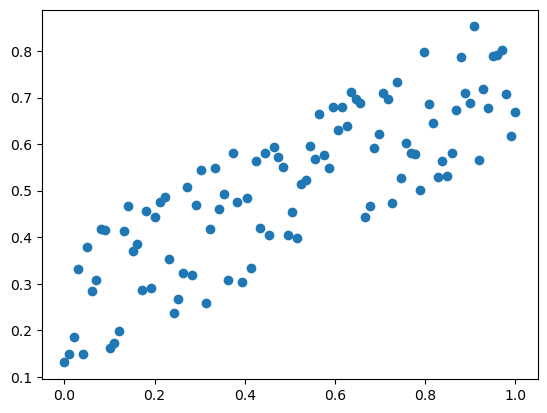

In [91]:
import numpy as np
import matplotlib.pyplot as plt

X = np.linspace(start=0, stop=1, num=100)
y = (0.5 * X) + 0.1 + 0.3 * np.random.rand(100)
plt.scatter(x=X, y=y)
plt.show()

Ara fem el procés de calcular $\hat{\theta}$ amb les equacions normals.

In [92]:
X = np.c_[np.ones_like(X), X]

In [93]:
theta = np.random.rand(2)

Crearem dos funcions. Una per calcular MSE i un altre per a calcular, el vector de gradient del MSE

In [94]:
def mse(X, y, theta):
    """Returns the Mean Squared Error.
    
    # Arguments:
        X, np.ndarray: the intput training data with `1`s appended to each row.
        y, np.ndarray: the targets of the training rows.
        theta, np.ndarray: the parameter vector of the model.
    
    # Returns
        MSE, float: Mean Squared Error between `X*theta` and `y`.
    """
    m = X.shape[0]
    X_theta = np.matmul(X, theta)
    return 1./m * np.matmul((X_theta - y).T, (X_theta - y)) # Multipliquem la transposada de (X*theta - y) per (X*theta - y) i dividim per m

In [95]:
mse(X, y, theta)

np.float64(0.07011275716570395)

In [96]:
def grad_mse(X, y, theta):
    """Returns MSE's Gradient Vector.
    
    # Arguments
        X, np.ndarray: the intput training data with `1`s appended to each row.
        y, np.ndarray: the targets of the training rows.
        theta, np.ndarray: the parameter vector of the model.
    
    # Results
        grad_mse, np.ndarray: the gradient vector of the mean squared error function. 
    """
    m = X.shape[0]
    X_theta = np.matmul(X, theta)
    return 2./m * np.matmul(X.T, X_theta - y) # Multipliquem la transposada de X per (X*theta - y) i dividim per m

In [97]:
grad_mse(X, y, theta)

array([-0.43668789, -0.28547311])

In [98]:
lr = 0.01

Hem definit un `learning rate` (lr) i després anem iterant, multiplicant el `learning rate` per el gradient i restant a theta. Això millora els dos parametres i, per tant, reduïm el `mse`. Hem posat dos límits a l'entrenament: 0.01 de MSE i 100 pasos.

In [99]:
step=0
theta = np.random.rand(2)
thetas = []
while mse(X, y, theta) > 0.01:
    theta = theta - lr * grad_mse(X, y, theta)
    if step % 10 == 0:
        print(mse(X, y, theta), theta)
        thetas.append(theta)
    step += 1
    if step > 100:
        break

0.07846051340542155 [0.25567338 0.95057912]
0.055044323291873046 [0.21578815 0.92286946]
0.04091846199252726 [0.18550021 0.90038773]
0.03235373439164493 [0.16262803 0.88196366]
0.027119027600970336 [0.14548434 0.86669188]
0.023879474644948807 [0.13276419 0.85387192]
0.021836399380123092 [0.12345833 0.8429618 ]
0.020511909629739006 [0.11678623 0.83354216]
0.019620027664279397 [0.11214426 0.82528843]
0.018989592577765526 [0.10906564 0.8179494 ]
0.01851813575676746 [0.10718939 0.8113306 ]


In [100]:
print(mse(X, y, theta), theta)

0.01851813575676746 [0.10718939 0.8113306 ]


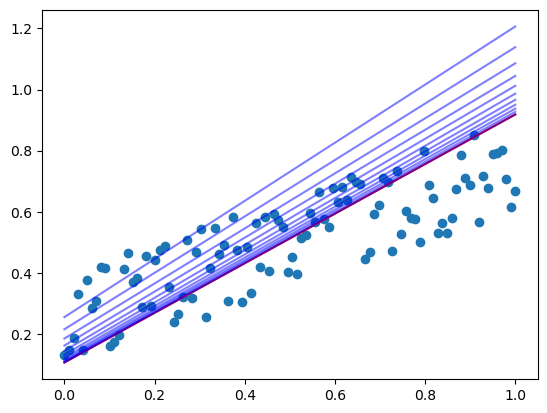

In [101]:
plt.scatter(x=X[:,1], y=y)
plt.plot([0,1], [theta[0] + theta[1]*0, theta[0] + theta[1]*1], color='red')
for theta in thetas:
    plt.plot([0,1], [theta[0] + theta[1]*0, theta[0] + theta[1]*1], color='blue', alpha=0.5)
plt.show()

Es dibuixen les línies del procés fins a la final. Es veu com van aproximant-se. Prova a canviar el `lr` per veure si no arriba a convergir o si ho fa massa ràpid i s'en passa. 

## Exemple de Stochastic Gradient Descent

El problema de fet el gradient en Batch és que utilitza tot el dataset. Això ens dona bons resultats, però amb `training set` molt grans és lent i ocupa massa memòria. 

El cas contrari, el `Stochastic Gradient Descent` sols agafa un punt i calcula el gradient i actualitza els paràmetres basat en eixe punt. L'algorisme és molt ràpid i permet entrenar amb dades massives. Per altra banda no és estable i la funció no descendeix gradualment, va botant. 

Per una altra banda, si la curva de pèrdudes és irregular, SGD eixirà més fácilment de mínims locals. Això és bo per escapar de mínims locals i roin per afinar realment a un mínim. Un `learning rate` alt permet escapar, però pot no arribar mai a un mínim òptim. Si es baix arribará a mínims, però pot ser que locals. Per arreglar eixa situació, comencem amb un `lr` alt i va baixant amb una funció anomenada `learning rate scheduler`.  

5.2834631161707625e-05
[0.3137536  0.39551518]


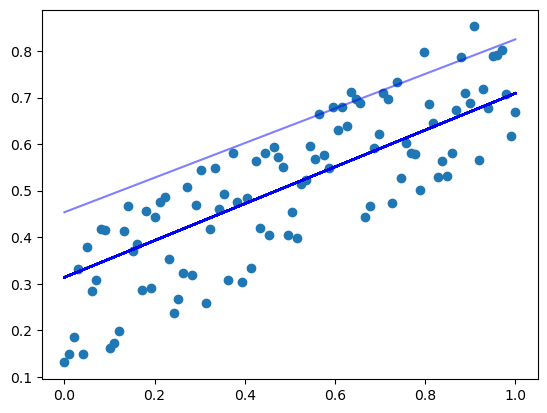

In [102]:
def sgd_loss(X_i, y_i, theta):
    """Returns the Mean Squared Error for Stochastic gradient descent.
    
    # Arguments:
        X_i, np.ndarray shape=(1,n): the intput training data row vector with `1` in the beginning.
        y, np.ndarray shape=(1,1): the target of the training row.
        theta, np.ndarray shape=(n,1): the parameters vector of the model.
    
    # Returns
        MSE, float: Mean Squared Error between `X*theta` and `y`.
    """
    X_theta = np.matmul(X_i, theta)
    return (X_theta - y_i)**2

def grad_sgd_loss(X_i, y_i, theta):
    """Returns Stochastic Gradient Descent's Mean Squared Error Gradient.
    
    # Arguments
        X_i, np.ndarray shape=(1,n): the intput training data row vector with `1` in the beginning.
        y, np.ndarray shape=(1,1): the target of the training row.
        theta, np.ndarray shape=(n,1): the parameters vector of the model.
    
    # Results
        grad_mse, np.ndarray: the gradient vector of the mean squared error function. 
    """
    X_theta = np.matmul(X_i, theta)
    return 2. * X_i.T * (X_theta - y_i)

def learning_rate_scheduler(lr, perc):
    """Returns annealed learning rate based on current one & reduction percentage
    
    # Arguments
        lr: float, initial learning rate
        perc: float in [0,1]: annealing percentage
    
    # Returns
        next_lr: float, next learning rate to use
    """
    return perc * lr

theta = np.random.rand(2)
lr, steps = 0.1, 100000

thetas = []
for _ in range(steps):
    random_idx = np.random.randint(low=0, high=X.shape[0])
    lr = learning_rate_scheduler(lr, perc=0.99) 
    theta = theta - lr * grad_sgd_loss(X[random_idx], y[random_idx], theta)
    if _ % 1000 == 0:
        #print(sgd_loss(X[random_idx], y[random_idx], theta))
        thetas.append(theta)


print(sgd_loss(X[random_idx], y[random_idx], theta))
print(theta)

plt.scatter(x=X[:,1], y=y)
plt.plot([0,1], [theta[0] + theta[1]*0, theta[0] + theta[1]*1], color='red')
for theta in thetas:
    plt.plot([0,1], [theta[0] + theta[1]*0, theta[0] + theta[1]*1], color='blue', alpha=0.5)
plt.show()

## Mini-Batch Gradient Descent


A cada pas, en lloc de calcular els gradients en una sola instància seleccionada aleatòriament (SGD) o en el conjunt d'entrenament complet (BGD), el descens de gradient per lots en miniatura calcula els seus gradients en un conjunt d'instàncies seleccionades aleatòriament. Les mostres s'anomenen **Mini-Batches**

El principal avantatge de MBGD respecte a SGD és l'augment de rendiment en les operacions matricials que s'obté especialment de les GPU. Intuïtivament, el procés d'optimització de paràmetres de MBGD és menys erràtic que el de SGD perquè la mostra alimentada és més representativa que un punt seleccionat aleatòriament, especialment per a mides de mini-lots grans.

No hem d'oblidar que el descens de gradient per lots triga molt a convergir perquè calculem els gradients sobre tot el conjunt d'entrenament a cada pas.

**SGD i MBGD també convergiran al mínim si fem servir un bon programa de taxa d'aprenentatge**

## Curva d'aprenentatge

Quan estem entrenant, si afegim complexitat al model poden tenir uns errors mínims durant l'entrenament. El risc és arribar a una situació d'`Overfitting` on el model ha aprés de memòria les dades d'entrenament i no ha generalitzat. 

Si funciona molt pitjor amb les dades de test, segurament és Overfitting. 

Una altra manera és generar un curva d'aprenentatge on es compara el rendiment de les dades d'entrenament front a les dades de test. 

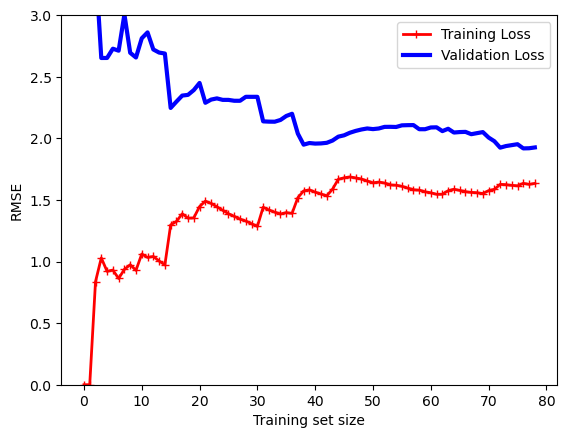

In [114]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

def plot_learning_curve(model, X, y):
    """Plots model training/validation's MSE over different sizes of training sets.
    
    # Arguments
        model: sklearn.*, a scikit-learn model to be trained/tested.
        X: np.ndarray, the input dataset.
        y: np.ndarray, the output dataset.
    """
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)
    train_errors, val_errors = list(), list()
    for m in range(1, X_train.shape[0]):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_test)
        train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_test, y_val_predict))
    plt.plot(np.sqrt(train_errors), 'r-+', linewidth=2, label='Training Loss')
    plt.plot(np.sqrt(val_errors), 'b-', linewidth=3, label='Validation Loss')
    plt.xlabel('Training set size')
    plt.ylabel('RMSE')
    plt.ylim([0, 3])
    plt.legend(loc='upper right')
    plt.show()


lin_reg = LinearRegression()
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)
plot_learning_curve(lin_reg, X, y)


Quan hi ha `1` o `2` instàncies al conjunt d'entrenament, el model les pot ajustar perfectament. Però quan afegim més dades d'entrenament, esdevé impossible que el model s'ajusti perfectament a tots els punts. Tant perquè les dades són sorolloses com perquè les dades no són gens lineals.

L'`RMSE` d'entrenament convergeix a una fase estable i si afegim més dades, l'RMSE no es veu afectat tant. D'altra banda, quan el model s'entrena en unes poques instàncies, no és capaç de generalitzar bé, d'aquí les pèrdues per a `val`.

A mesura que es mostren més exemples al model, aprèn patrons generals i l'error `val` convergeix a l'error d'entrenament.

**Aquestes corbes són típiques d'un model que està `underfitting`**.

Si el nostre model està underfitting les dades, **afegir més punts de dades no ajudarà**, hem d'**afegir més característiques o utilitzar un model més complex**.

Ajustem i visualitzem les corbes d'un model polinòmic de 10 graus:

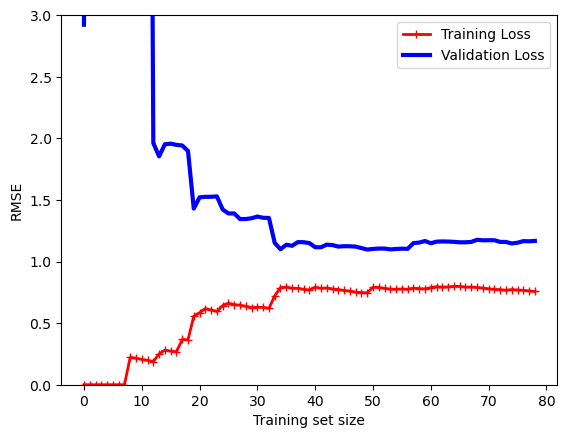

In [116]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

polynomial_regression = Pipeline([
    ('poly_features', PolynomialFeatures(degree=10, include_bias=False)),
    ('lin_reg', LinearRegression())
])

plot_learning_curve(polynomial_regression, X, y)

Aquestes corbes d'aprenentatge s'assemblen molt a les anteriors, però hi ha algunes diferències clau:
- L'error a les dades d'entrenament és molt menor que en l'exemple anterior.
- Hi ha una **bretxa** entre les corbes, cosa que significa que el model funciona molt millor en el conjunt d'entrenament que en el conjunt de validació. La qual cosa és la característica distintiva d'un model de Overfitting.

Una solució al Overfitting **és tenir més dades d'entrenament fins que la pèrdua de validació arribi a la pèrdua d'entrenament**.

Un resultat teòric important de l'estadística i l'aprenentatge automàtic és que l'error de generalització es pot expressar com la suma de tres errors molt diferents:

**Biaix**: Té a veure amb suposicions errònies, com ara assumir que les dades són lineals quan en realitat són quadràtiques. Un model d'alt biaix té més probabilitats de subajustar les dades d'entrenament.

**Variància**: Té a veure amb l'excessiva sensibilitat d'un model a les dades d'entrenament. Un model d'alta variància tendeix a sobreajustar les dades d'entrenament.

Cada conjunt de dades té el que anomenem **error irreductible** (el soroll de les dades en si). L'única manera de reduir aquest error és corregir les dades. Augmentar la complexitat d'un model normalment augmentarà la seva variància i disminuirà el biaix (amb un model menys restringit). Reduir la complexitat del model augmentarà el biaix i disminuirà la variància.

Això és el que anomenem el compromís `bias-variance`.